In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DIR = "KAGGLE_RESULTS_FIX/global_summary_yeojohnson_denormalized.csv"
result = pd.read_csv(DIR)
result

,datetime_run,feature_type,horizon,model_name,mape_train_denorm,mape_test_denorm
0,2026-04-27 09:29:19,UNIVARIATE,24h,LSTM,3.2507,4.3429
1,2026-04-27 09:51:18,UNIVARIATE,24h,BiLSTM,3.1365,4.1889
2,2026-04-27 10:00:52,UNIVARIATE,24h,Attention,15.1518,15.1432
3,2026-04-27 10:17:03,UNIVARIATE,48h,LSTM,4.5089,5.8991
4,2026-04-27 10:39:09,UNIVARIATE,48h,BiLSTM,4.1971,5.8814
5,2026-04-27 10:48:51,UNIVARIATE,48h,Attention,16.0875,16.1272
6,2026-04-27 11:05:03,MULTIVARIATE,24h,LSTM,2.6921,4.9613
7,2026-04-27 11:26:56,MULTIVARIATE,24h,BiLSTM,2.2947,4.9980
8,2026-04-27 11:37:52,MULTIVARIATE,24h,Attention,13.2153,13.9833
9,2026-04-27 11:54:04,MULTIVARIATE,48h,LSTM,3.6003,6.8310


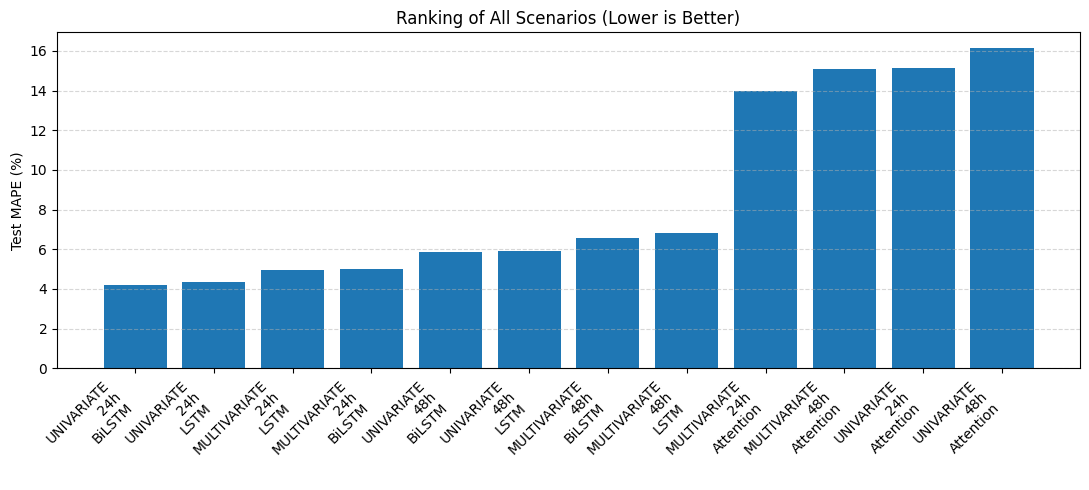

In [3]:
best = result.sort_values("mape_test_denorm")

plt.figure(figsize=(11,5))

labels = (
    best["feature_type"] + "\n" +
    best["horizon"] + "\n" +
    best["model_name"]
)

plt.bar(labels, best["mape_test_denorm"])

plt.ylabel("Test MAPE (%)")
plt.title("Ranking of All Scenarios (Lower is Better)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

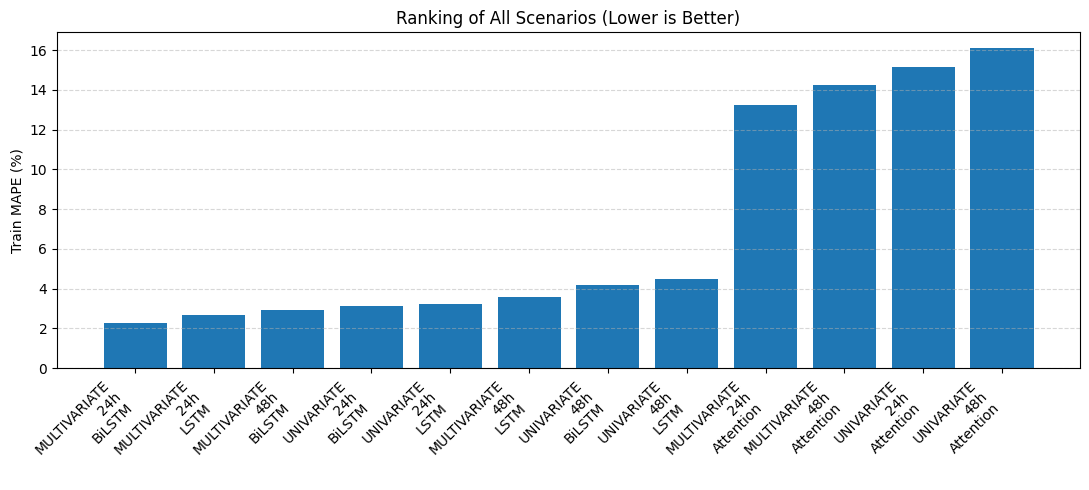

In [6]:
best = result.sort_values("mape_train_denorm")

plt.figure(figsize=(11,5))

labels = (
    best["feature_type"] + "\n" +
    best["horizon"] + "\n" +
    best["model_name"]
)

plt.bar(labels, best["mape_train_denorm"])

plt.ylabel("Train MAPE (%)")
plt.title("Ranking of All Scenarios (Lower is Better)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

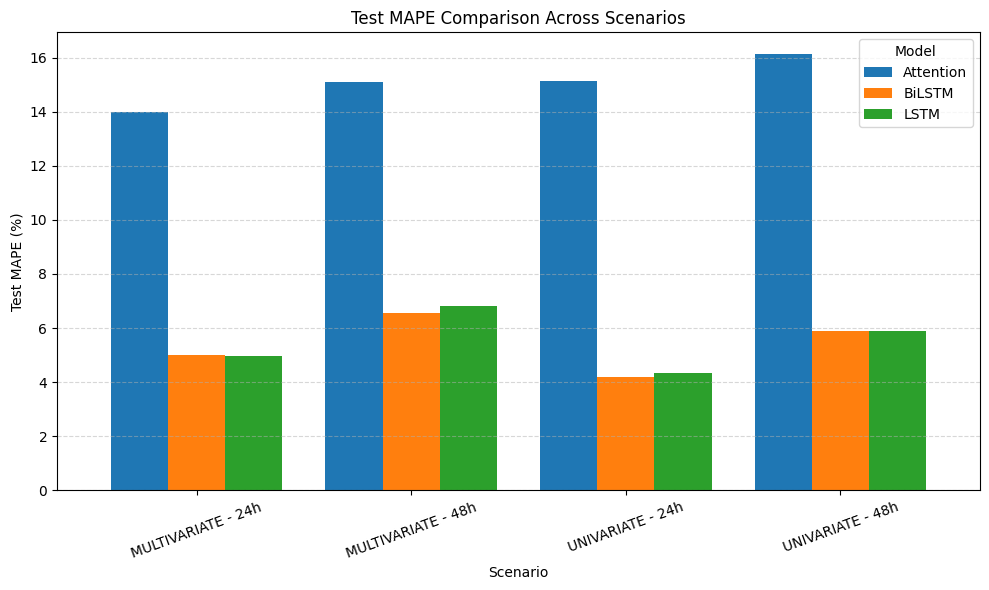

In [4]:
# Create scenario label
result["scenario"] = result["feature_type"] + " - " + result["horizon"]

# Pivot table
pivot = result.pivot(
    index="scenario",
    columns="model_name",
    values="mape_test_denorm"
)

# Plot
ax = pivot.plot(
    kind="bar",
    figsize=(10,6),
    width=0.8
)

plt.title("Test MAPE Comparison Across Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Test MAPE (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

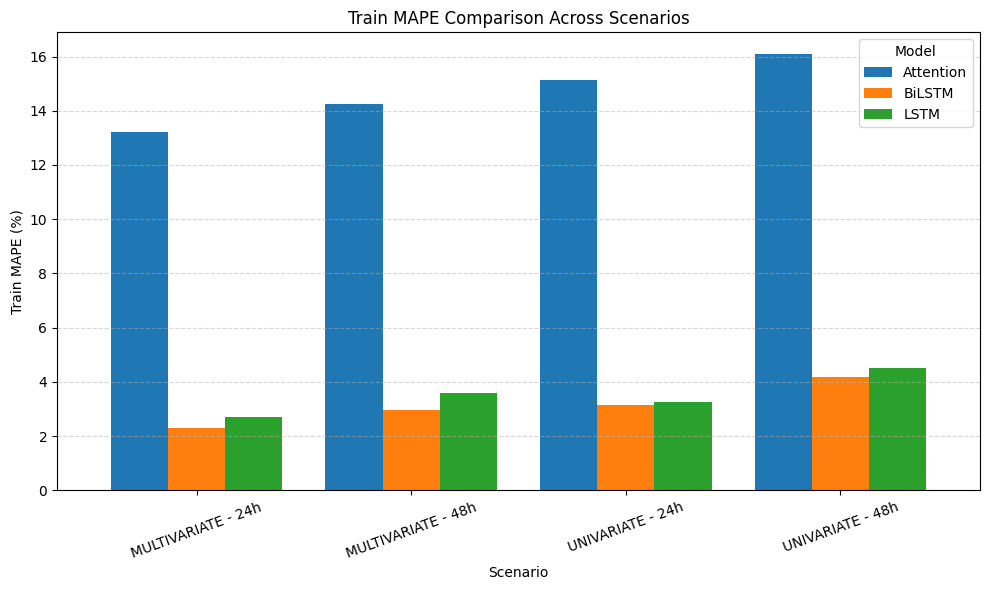

In [5]:
# Create scenario label
result["scenario"] = result["feature_type"] + " - " + result["horizon"]

# Pivot table
pivot = result.pivot(
    index="scenario",
    columns="model_name",
    values="mape_train_denorm"
)

# Plot
ax = pivot.plot(
    kind="bar",
    figsize=(10,6),
    width=0.8
)

plt.title("Train MAPE Comparison Across Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Train MAPE (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Model")
plt.tight_layout()
plt.show()